# Hito 4 — Experimentos del Recomendador (Semana 11)

Notebook complementario al pipeline `src/`. Concentra la **inspección visual y comparativa** que respalda el informe LaTeX.

Secciones:
1. Datos y construcción de R.
2. TF-IDF sobre el catálogo (recomendador de contenido).
3. Comparativa de encodings y sparsity.
4. Normalizaciones y su impacto.
5. Filtrado colaborativo: ítem-ítem y ALS + lambda iteration.
6. Cold-start: comparativa cuantitativa.
7. Recomendador híbrido y ablación de pesos.

In [1]:
import json
from pathlib import Path
import numpy as np, pandas as pd, scipy.sparse as sp
import matplotlib.pyplot as plt

REC = Path('..') / 'data' / 'recommender'
sorted(p.name for p in REC.iterdir())

['README.md',
 'R_household_bin.npz',
 'R_household_count.npz',
 'R_kitchen_bin.npz',
 'R_kitchen_count.npz',
 'R_restock_bin.npz',
 'R_restock_count.npz',
 'R_restock_freq.npz',
 'R_restock_l2_row.npz',
 'R_restock_log1p.npz',
 'R_restock_qty.npz',
 'R_restock_raw.npz',
 'R_restock_row_mean_center.npz',
 'R_restock_tfidf_R.npz',
 'als_X.npy',
 'als_Y.npy',
 'als_meta.json',
 'cold_start_product.csv',
 'cold_start_session.csv',
 'cold_start_session_2seed.csv',
 'cold_start_summary.json',
 'content_features_meta.json',
 'error_analysis.csv',
 'evaluation_summary.json',
 'evaluation_table.csv',
 'hybrid_ablation.csv',
 'hybrid_meta.json',
 'hybrid_top10_hh0.csv',
 'item_sim_cf_cosine.npy',
 'item_sim_cf_dot.npy',
 'item_sim_content.npy',
 'lambda_sweep.csv',
 'normalization_summary.json',
 'product_catalog.csv',
 'products.json',
 'sessions_kitchen.json',
 'sessions_restock.json',
 'sparsity_report.json',
 'tfidf_items.npz',
 'tfidf_vocab.json']

## 1. Construcción de R

Definimos la unidad de sesión como **ventana de restock de 60 min** sobre eventos `IN` por household, alineado con la definición operacional de la propuesta. Para CF implícito esto da 1,177 sesiones × 50 productos con 17 % de densidad — sparsity realista para un dataset de hogar.

In [2]:
spar = pd.DataFrame(json.load(open(REC/'sparsity_report.json')))
spar

,matrix,shape,nnz,density,sparsity,row_nnz_mean,row_nnz_min,row_nnz_max,col_nnz_mean,col_nnz_min,col_nnz_max
0,R_restock_bin,"[1177, 50]",10260,0.174342,0.825658,8.717077,3,27,205.20,180,233
1,R_restock_count,"[1177, 50]",10260,0.174342,0.825658,8.717077,3,27,205.20,180,233
2,R_restock_qty,"[1177, 50]",10260,0.174342,0.825658,8.717077,3,27,205.20,180,233
3,R_restock_freq,"[1177, 50]",10260,0.174342,0.825658,8.717077,3,27,205.20,180,233
4,R_kitchen_bin,"[8075, 50]",13707,0.033949,0.966051,1.697461,1,22,274.14,246,312
5,R_kitchen_count,"[8075, 50]",13707,0.033949,0.966051,1.697461,1,22,274.14,246,312
6,R_household_bin,"[10, 50]",500,1.000000,0.000000,50.000000,50,50,10.00,10,10
7,R_household_count,"[10, 50]",500,1.000000,0.000000,50.000000,50,50,10.00,10,10


## 2. TF-IDF sobre el catálogo

Cada producto se convierte en un documento concatenando nombre, categoría, nutriscore y buckets nutricionales. TF-IDF L2-normalizado: `cosine_sim = dot product`.

Tokens con IDF mínimo = términos ubicuos (organic, class_purchase) — el sistema los desentona automáticamente.
Tokens con IDF máximo = términos distintivos (cilantro, zucchini, category_8) — son los que diferencian un perfil de otro.

In [3]:
X = sp.load_npz(REC/'tfidf_items.npz')
print('shape:', X.shape, 'nnz:', X.nnz)
cat = pd.read_csv(REC/'product_catalog.csv')
cat[['product_id','product_name','category','nutriscore','doc']].head()

shape: (50, 82) nnz: 391


,product_id,product_name,category,nutriscore,doc
0,4605,Yellow Onions,4,A,yellow onions category_4 class_purchase
1,4920,Seedless Red Grapes,4,B,seedless red grapes category_4 class_purchase
2,5077,100% Whole Wheat Bread,3,C,100% whole wheat bread category_3 class_consum...
3,5876,Organic Lemon,4,D,organic lemon category_4 class_purchase
4,8277,Apple Honeycrisp Organic,4,Falta Dato,apple honeycrisp organic category_4 class_purc...


## 3. Comparativa de encodings

El caso base **household × producto** (10 × 50) tiene densidad 100 %: todos los hogares han tocado todos los productos, por lo que el CF a ese nivel es degenerado. La unidad de **sesión** introduce sparsity y permite que el dot product entre columnas signifique co-ocurrencia genuina.

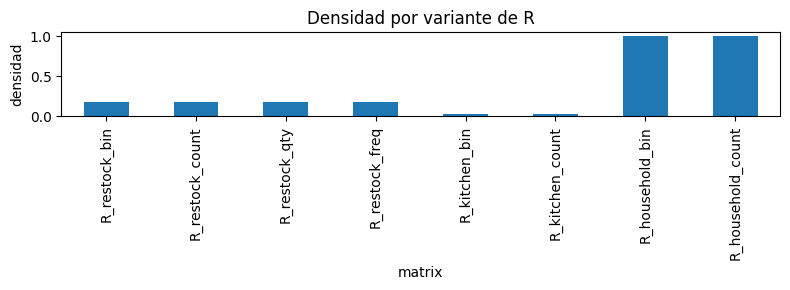

In [4]:
ax = spar.set_index('matrix')['density'].plot.bar(figsize=(8,3), color='#1f77b4')
ax.set_ylabel('densidad'); ax.set_title('Densidad por variante de R'); plt.tight_layout()

## 4. Normalizaciones

Se aplican 5 normalizaciones sobre `R_restock_count` y se compara la distribución de valores no-cero. `tfidf_R` y `l2_row` son las que mejor preparan la matriz para ALS y para cosine sim ítem-ítem.

In [5]:
summary = json.load(open(REC/'normalization_summary.json'))
pd.DataFrame(summary).T

,shape,nnz,mean,std,min,max,median
raw,"[1177, 50]",10260,1.104971,0.333326,1.0,4.0,1.0
row_mean_center,"[1177, 50]",10260,-0.0,0.311883,-0.692308,2.785714,0.0
log1p,"[1177, 50]",10260,0.734735,0.129439,0.693147,1.609438,0.693147
tfidf_R,"[1177, 50]",10260,2.014147,0.357603,1.813448,4.545937,1.898429
l2_row,"[1177, 50]",10260,0.324266,0.097822,0.129099,0.904534,0.301511


## 5. Filtrado colaborativo y lambda iteration

Implementación propia de **ALS implícito** (Hu/Koren/Volinsky 2008). Se barrió λ ∈ {0.001, 0.01, 0.1, 0.5, 1, 5, 10} con `factors=16`, `alpha=20`, 8 iteraciones, hold-out 20 % de las interacciones.

In [6]:
sweep = pd.read_csv(REC/'lambda_sweep.csv')
sweep

,lambda,precision@k,recall@k
0,0.001,0.046901,0.103071
1,0.010,0.048554,0.106643
2,0.100,0.047107,0.109148
3,0.500,0.048554,0.113910
4,1.000,0.049380,0.116303
5,5.000,0.048347,0.113547
6,10.000,0.048760,0.114986


## 6. Cold-start

Para **sesión cold** (1 ó 2 productos seed), `partial_cf` (k-NN ítem-ítem CF) supera a popularidad pura y a content-only. Para **producto cold**, content-only es la única estrategia viable (no hay historial CF); recupera productos co-ocurrentes con precision@5 ≈ 0.80.

In [7]:
cs1 = pd.read_csv(REC/'cold_start_session.csv')
cs2 = pd.read_csv(REC/'cold_start_session_2seed.csv')
pd.DataFrame({
    '1_seed': cs1.filter(regex='prec@5').mean(),
    '2_seed': cs2.filter(regex='prec@5').mean(),
})

,1_seed,2_seed
prec@5_popularity,0.172472,0.154460
nprec@5_popularity,0.176664,0.164387
prec@5_partial_cf,0.194053,0.185047
nprec@5_partial_cf,0.197621,0.196163
prec@5_content_only,0.158029,0.139507
nprec@5_content_only,0.160903,0.147338
prec@5_mixed,0.163806,0.145794
nprec@5_mixed,0.167984,0.154673


## 7. Recomendador híbrido

Combinación lineal de los tres scorings, normalizados a [0, 1]. La señal `score_expiry` no mejora precision@5 sobre hold-out (no es un problema de hit), pero introduce el objetivo anti-desperdicio característico de SKI: empuja productos del inventario actual con vencimiento próximo.

In [8]:
abl = pd.read_csv(REC/'hybrid_ablation.csv')
abl.sort_values('precision@5', ascending=False)

,w_C,w_F,w_E,precision@5
3,0.50,0.50,0.0,0.113
5,0.25,0.45,0.3,0.110
1,0.00,1.00,0.0,0.107
0,1.00,0.00,0.0,0.100
2,0.00,0.00,1.0,0.095
4,0.35,0.45,0.2,0.087
